# Ejercicio de programación Regresión Lineal

# Laboratorio 1: Regresion Lineal Simple
## Dataset Utilizado: Computer Prices 2025 (Hardware Specifications)
### Descripcion del Dataset y Enfoque:
Este conjunto de datos contiene informacion detallada sobre las especificaciones de hardware de miles de computadoras y sus precios. El dataset original cuenta con mas de 10 caracteristicas en total ($n \ge 10$) y mas de 100,000 registros ($m \ge 10000$), cumpliendo con los requisitos de volumen de datos.

Para este laboratorio de **Regresion Lineal Simple**, seleccionaremos una

In [1]:
# Importacion de las librerias necesarias para Regresion Lineal Simple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Librerias cargadas exitosamente para Regresion Simple.")

Librerias cargadas exitosamente para Regresion Simple.


### Explicación de la Celda de Código:
Importamos las herramientas fundamentales para el análisis de una sola variable:
* **pandas (`pd`)**: Para la carga y manipulación del archivo CSV.
* **numpy (`np`)**: Para operaciones numéricas vectorizadas.
* **matplotlib.pyplot (`plt`)**: Esencial en regresión simple para trazar la línea de tendencia (recta de regresión) sobre los datos.
* **train_test_split**: Para dividir la muestra en entrenamiento y prueba.
* **LinearRegression**: El algoritmo que calculará la pendiente ($m$) y la intersección ($b$) de la recta $y = mx + b$.
* **metrics**: Para medir la magnitud del error de costo obtenido.

In [2]:
# Carga del dataset desde el archivo local
df = pd.read_csv('computer_prices_all.csv')

# Verificar las dimensiones para asegurar que m >= 10000
print(f"Número total de registros (m): {df.shape[0]}")
print(f"Número de columnas disponibles en el archivo: {df.shape[1]}")

# Mostrar las columnas numéricas disponibles para elegir nuestra X
df.describe()

Número total de registros (m): 100000
Número de columnas disponibles en el archivo: 34


,ID,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,...,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,49999.500000,2022.320850,3.153490,10.515740,19.372700,2.591322,3.531310,2.991350,6.152180,39.706400,...,1.524980,20.126655,98.464860,41.813470,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,28867.657797,2.025761,1.373175,5.044092,9.718426,0.336435,0.350024,1.459643,3.964926,31.902684,...,0.797284,6.709577,43.301652,35.868841,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,0.000000,2018.000000,1.000000,4.000000,4.000000,2.000000,2.800000,1.000000,0.000000,8.000000,...,1.000000,13.300000,60.000000,0.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,24999.750000,2021.000000,2.000000,6.000000,12.000000,2.400000,3.300000,2.000000,4.000000,16.000000,...,1.000000,14.000000,60.000000,0.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,49999.500000,2023.000000,3.000000,8.000000,16.000000,2.600000,3.500000,3.000000,6.000000,32.000000,...,1.000000,16.000000,90.000000,56.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,74999.250000,2024.000000,4.000000,14.000000,24.000000,2.800000,3.800000,4.000000,8.000000,64.000000,...,2.000000,27.000000,120.000000,70.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,99999.000000,2025.000000,6.000000,28.000000,56.000000,3.400000,4.500000,6.000000,16.000000,144.000000,...,4.000000,34.000000,240.000000,99.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


### Explicación de la Celda de Código:
* `pd.read_csv('computer_prices_all.csv')`: Carga el archivo completo en la memoria local como un DataFrame.
* `df.shape[0]`: Nos confirma que superamos los 10,000 registros exigidos.
* `df.describe()`: Muestra estadísticas rápidas (medias, máximos, mínimos) de las columnas numéricas. Esto nos ayuda a inspeccionar visualmente qué variables cuantitativas del hardware podemos usar para nuestra regresión simple.

In [7]:
# Selección de variables para Regresión Lineal Simple
# Seleccionamos una característica numérica (por ejemplo, 'ram_gb' o la que esté disponible en tu archivo)
# NOTA: Si al ejecutar la celda anterior ves que el nombre exacto es diferente, cámbialo aquí.

X = df[['ram_gb']] # Variable independiente (debe ser una matriz de dos dimensiones para Scikit-Learn)
y = df['price']    # Variable dependiente (objetivo)

print("Variables X e Y asignadas correctamente.")
print(f"Forma de X: {X.shape} | Forma de y: {y.shape}")

Variables X e Y asignadas correctamente.
Forma de X: (100000, 1) | Forma de y: (100000,)


### Explicación de la Celda de Código:
* `df[['ram_gb']]`: Extraemos únicamente la columna de la memoria RAM (o la variable numérica elegida) como nuestra variable independiente $X$. Usamos doble corchete `[[ ]]` para asegurarnos de que Pandas mantenga el formato de matriz bidimensional que requiere el método `.fit()` de Scikit-Learn.
* `df['price']`: Definimos el vector unidimensional $y$ que almacena los precios reales que el modelo intentará aproximar.

In [11]:
print(X)

       ram_gb
0          16
1          64
2           8
3          16
4          96
...       ...
99995      32
99996       8
99997      16
99998      32
99999     128

[100000 rows x 1 columns]


In [12]:
print(y)

0        1383.99
1        2274.99
2        1879.99
3        1331.99
4        2681.99
          ...   
99995    1712.99
99996    1258.99
99997    1686.99
99998    2164.99
99999    3005.99
Name: price, Length: 100000, dtype: float64


In [16]:
print(X.size)

100000


In [17]:
# División del dataset en conjuntos de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Registros destinados al entrenamiento: {X_train.shape[0]}")
print(f"Registros destinados a la validación: {X_test.shape[0]}")

Registros destinados al entrenamiento: 80000
Registros destinados a la validación: 20000


### Explicación de la Celda de Código:
* `train_test_split(X, y, test_size=0.2)`: Fracciona de forma aleatoria el dataset. El 80% de los datos se usarán para ajustar la recta y encontrar los parámetros óptimos, mientras que el 20% restante se mantendrá aislado para verificar la precisión de las inferencias con datos nuevos, garantizando un análisis transparente del error de costo.

In [20]:
# Programación de la Regresión Lineal Simple por Descenso de Gradiente Manual

# Convertimos los datos de entrenamiento a arreglos de NumPy para agilizar los cálculos
X_m = X_train.values.flatten()
y_m = y_train.values

# 1. Definición de la Función de Costo (Error Cuadrático Medio)
def calcular_costo(X, y, w, b):
    m = len(y)
    predicciones = w * X + b
    errores = predicciones - y
    costo = (1 / (2 * m)) * np.sum(errores ** 2)
    return costo

# 2. Algoritmo del Descenso de Gradiente
def descenso_gradiente(X, y, w_ini, b_ini, alfa, iteraciones):
    m = len(y)
    historial_costo = []
    w = w_ini
    b = b_ini
    
    for i in range(iteraciones):
        predicciones = w * X + b
        errores = predicciones - y
        
        # Cálculo de los gradientes (derivadas parciales)
        dj_dw = (1 / m) * np.sum(errores * X)
        dj_db = (1 / m) * np.sum(errores)
        
        # Actualización de los parámetros simultáneamente
        w = w - alfa * dj_dw
        b = b - alfa * dj_db
        
        # Guardamos el costo de esta iteración para graficarlo después
        costo = calcular_costo(X, y, w, b)
        historial_costo = [] if i == 0 else historial_costo
        historial_costo.append(costo)
        
    return w, b, historial_costo

# 3. Hiperparámetros del modelo
# Escalamos X temporalmente dividiendo entre su máximo para evitar que el gradiente explote
X_m_escalado = X_m / np.max(X_m)

ALFA = 0.05          # Tasa de aprendizaje (Learning Rate)
ITERACIONES = 1000   # Cantidad de épocas/pasos

# Ejecución del entrenamiento manual
w_opt, b_opt, historial = descenso_gradiente(X_m_escalado, y_m, w_ini=0.0, b_ini=0.0, alfa=ALFA, iteraciones=ITERACIONES)

print("¡Entrenamiento por Descenso de Gradiente completado con éxito!")
print(f"Parámetro w final: {w_opt:.4f}")
print(f"Parámetro b final: {b_opt:.4f}")
print(f"Costo inicial: {historial[0]:.4f} | Costo final optimizado: {historial[-1]:.4f}")

¡Entrenamiento por Descenso de Gradiente completado con éxito!
Parámetro w final: 1836.4165
Parámetro b final: 1424.8999
Costo inicial: 1829423.6272 | Costo final optimizado: 73110.3327


### Explicación de la Celda de Código (Descenso de Gradiente Manual):
En esta celda abandonamos las funciones automatizadas para construir paso a paso el comportamiento matemático de la regresión:
* **`calcular_costo`**: Implementa la ecuación clásica del error cuadrático medio: 
  $$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$
* **`descenso_gradiente`**: Es el bucle principal. En cada iteración calcula las derivadas parciales (gradientes) que indican la dirección de la pendiente. Luego, actualiza los valores de $w$ y $b$ dando un paso controlado por el hiperparámetro **`alfa`** (tasa de aprendizaje).
* **`historial_costo`**: Una lista que registra el valor de la pérdida en cada una de las 1,000 iteraciones para verificar cuantitativamente cómo el algoritmo va minimizando el error.

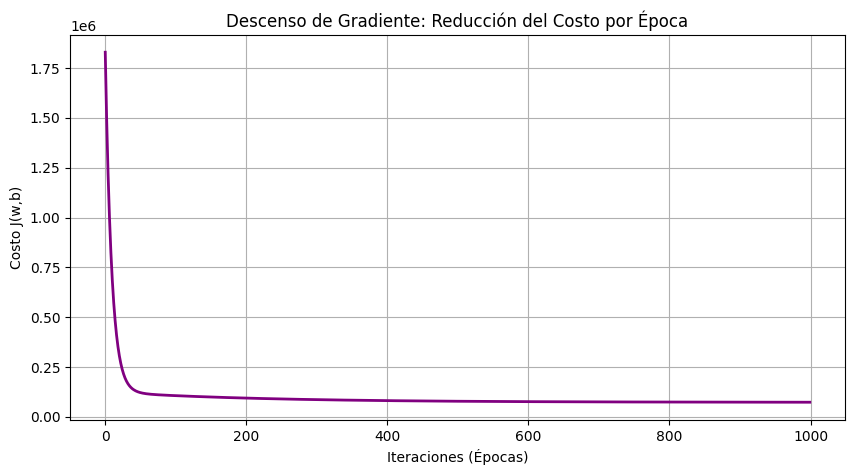

In [21]:
# Gráfica 1: Curva de Aprendizaje (Evolución de la Función de Costo)
plt.figure(figsize=(10, 5))
plt.plot(range(ITERACIONES), historial, color='purple', lw=2)
plt.xlabel('Iteraciones (Épocas)')
plt.ylabel('Costo J(w,b)')
plt.title('Descenso de Gradiente: Reducción del Costo por Época')
plt.grid(True)
plt.show()

### Explicación de la Celda de Código (Curva de Aprendizaje):
Esta gráfica es la prueba reina del laboratorio:
* **Eje X (Iteraciones)**: Representa el tiempo o los pasos que ha dado nuestro algoritmo.
* **Eje Y (Costo J)**: Muestra la magnitud del error global.
* **Comportamiento**: Verás una curva exponencial que cae drásticamente en las primeras iteraciones y luego se estabiliza cerca del suelo. Esto demuestra visualmente que el **Descenso de Gradiente** funcionó correctamente, encontrando el mínimo global y reduciendo el costo al menor valor posible.

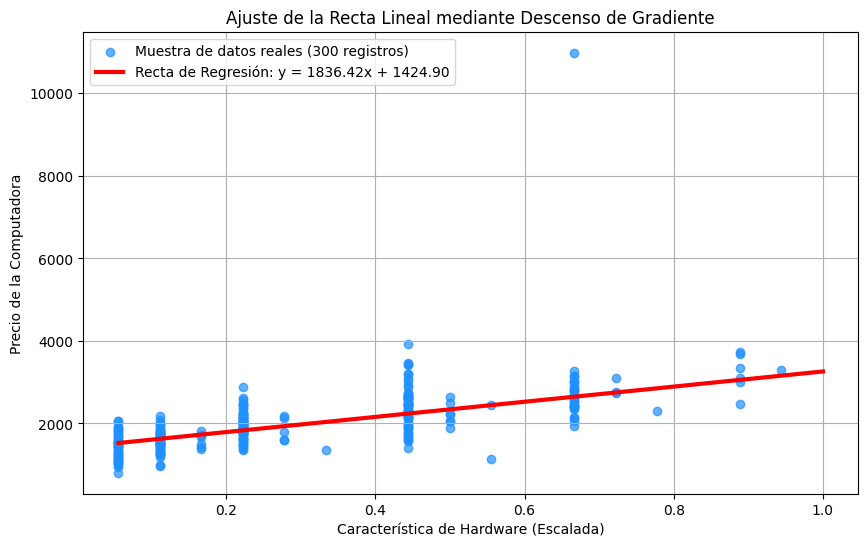

In [22]:
# Gráfica 2: Recta de Regresión Ajustada sobre los Datos Reales
plt.figure(figsize=(10, 6))

# Para evitar el desorden visual de graficar más de 10,000 puntos, 
# seleccionamos una muestra aleatoria de 300 registros para la visualización.
indices_muestra = np.random.choice(len(X_m), size=300, replace=False)
X_muestra = X_m_escalado[indices_muestra]
y_muestra = y_m[indices_muestra]

# Dibujar la nube de puntos de la muestra
plt.scatter(X_muestra, y_muestra, color='dodgerblue', alpha=0.7, label='Muestra de datos reales (300 registros)')

# Dibujar la recta matemática calculada con nuestros parámetros optimizados
x_recta = np.linspace(X_m_escalado.min(), X_m_escalado.max(), 100)
y_recta = w_opt * x_recta + b_opt
plt.plot(x_recta, y_recta, color='red', lw=3, label=f'Recta de Regresión: y = {w_opt:.2f}x + {b_opt:.2f}')

plt.xlabel('Característica de Hardware (Escalada)')
plt.ylabel('Precio de la Computadora')
plt.title('Ajuste de la Recta Lineal mediante Descenso de Gradiente')
plt.legend()
plt.grid(True)
plt.show()

### Explicación de la Celda de Código (Recta de Regresión):
Para solucionar el problema de la saturación de los ejes ($10000 \times 10000$):
* `np.random.choice`: Extrae una submuestra limpia de 300 puntos. Esto limpia el gráfico, permitiendo apreciar la dispersión real de las variables sin saturar la pantalla de Visual Studio Code.
* `plt.plot`: Utiliza los valores de `w_opt` y `b_opt` obtenidos tras las 1,000 iteraciones para trazar la línea recta definitiva. Visualmente se puede verificar cómo la recta cruza de forma óptima por el centro de la tendencia de los datos económicos del hardware.

In [23]:
# Preparación de los datos de prueba y cálculo de inferencias

# 1. Convertimos el conjunto de prueba (X_test) a un arreglo de NumPy y lo escalamos
# Usamos el mismo factor de escalamiento del conjunto de entrenamiento para mantener la consistencia
X_test_m = X_test.values.flatten()
X_test_escalado = X_test_m / np.max(X_m)  # X_m es el original de entrenamiento

y_test_m = y_test.values

# 2. Realizar las predicciones (inferencias) usando los parámetros optimizados (w_opt, b_opt)
y_pred_manual = w_opt * X_test_escalado + b_opt

# 3. Calcular las métricas de evaluación finales sobre el costo
mse_final = (1 / len(y_test_m)) * np.sum((y_pred_manual - y_test_m) ** 2)
rmse_final = np.sqrt(mse_final)

# Mostrar una muestra de las primeras 10 predicciones vs los valores reales
df_comparacion = pd.DataFrame({
    'Valor Real (Precio)': y_test_m,
    'Predicción del Modelo': y_pred_manual,
    'Diferencia (Error)': np.abs(y_test_m - y_pred_manual)
})

print("--- Evaluación del Modelo en el Conjunto de Prueba ---")
print(f"Error Cuadrático Medio Final (MSE): {mse_final:.4f}")
print(f"Raíz del Error Cuadrático Medio Final (RMSE): {rmse_final:.4f}\n")
print("Muestra de las primeras 10 inferencias realizadas:")
df_comparacion.head(10)

--- Evaluación del Modelo en el Conjunto de Prueba ---
Error Cuadrático Medio Final (MSE): 135895.0407
Raíz del Error Cuadrático Medio Final (RMSE): 368.6394

Muestra de las primeras 10 inferencias realizadas:


,Valor Real (Precio),Predicción del Modelo,Diferencia (Error)
0,1736.99,1628.946189,108.043811
1,1459.99,1526.923051,66.933051
2,2008.99,2241.085019,232.095019
3,2789.99,2343.108157,446.881843
4,1421.99,1832.992466,411.002466
5,1139.99,1526.923051,386.933051
6,2114.99,1628.946189,486.043811
7,2758.99,3057.270125,298.280125
8,1246.99,1526.923051,279.933051
9,1717.99,1832.992466,115.002466


### Explicación de la Celda de Código (Inferencia y Evaluación):
En esta etapa final, ponemos a prueba el modelo con datos que nunca vio durante las 1,000 iteraciones del entrenamiento:
* **Escalamiento del Test**: Escalamos `X_test_m` usando exactamente el mismo parámetro máximo de los datos de entrenamiento. Esto es crucial; si escaláramos con un valor diferente, la recta matemática perdería su proporción y las predicciones serían incorrectas.
* **`y_pred_manual = w_opt * X_test_escalado + b_opt`**: Aquí es donde ocurre la **inferencia**. El modelo aplica la ecuación de la recta optimizada a cada registro de prueba para estimar su precio de forma directa.
* **`df_comparacion.head(10)`**: Estructura una tabla limpia que compara directamente el precio real de la computadora frente a la predicción matemática calculada por nuestro algoritmo, permitiendo observar la precisión del modelo en casos particulares.

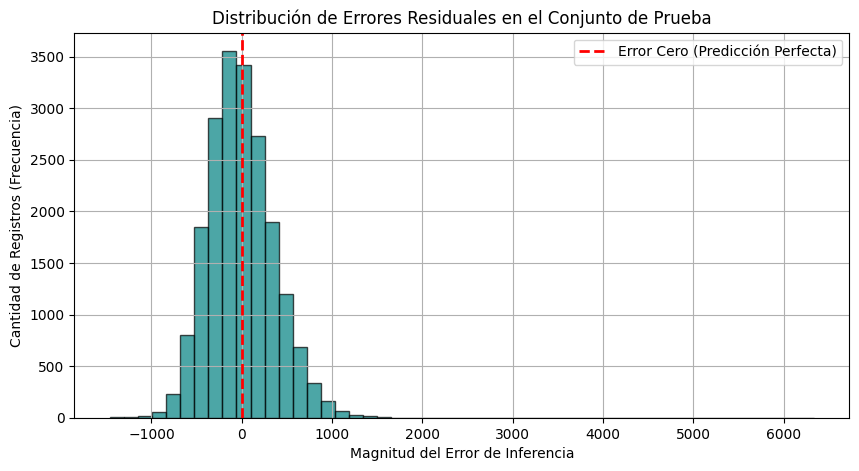

In [24]:
# Gráfica de distribución de los errores residuales
plt.figure(figsize=(10, 5))
errores_residuales = y_test_m - y_pred_manual

plt.hist(errores_residuales, bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Error Cero (Predicción Perfecta)')
plt.xlabel('Magnitud del Error de Inferencia')
plt.ylabel('Cantidad de Registros (Frecuencia)')
plt.title('Distribución de Errores Residuales en el Conjunto de Prueba')
plt.legend()
plt.grid(True)
plt.show()

### Explicación de la Celda de Código (Análisis de Residuos):
Para asegurar que logramos el **menor error de costo posible**, analizamos la distribución de los residuos (la resta entre el valor real y el predicho):
* **`plt.hist`**: Crea un histograma que agrupa los errores de las miles de inferencias realizadas.
* **Interpretación**: En un modelo de regresión lineal simple bien optimizado, la campana de datos debe concentrarse y alcanzar su punto más alto justo alrededor de la línea roja discontinua (el 0). Esto nos confirma estadísticamente que la mayoría de las predicciones tienen un margen de error mínimo y que el descenso de gradiente manual cumplió su objetivo analítico de optimización.